In [1]:
from pathlib import Path
import sys


def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "src" / "forestgeom").exists():
            return path
    raise RuntimeError("Could not find the project root containing pyproject.toml and src/forestgeom/.")


PROJECT_ROOT = find_project_root()
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from forestgeom import ForestProximity
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from dataset import dataprep


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Select ForestProximity parameters and Load the Data

In [2]:
seed = 42

forest_type = "rf"  # one of {"rf", "et", "xgb", "lgbm", "gbt"}

weight_scheme = "gap"

force_symmetric = False
adjust_diagonal = False


if forest_type == "rf":
    forest = RandomForestClassifier(
        max_samples=None,
        oob_score=True,
        bootstrap=True,
        n_estimators=100,
        verbose=1,
        n_jobs=-1,
        random_state=seed,
    )

elif forest_type == "et":
    forest = ExtraTreesClassifier(
        max_samples=None,
        oob_score=True,
        bootstrap=True,
        n_estimators=100,
        verbose=1,
        n_jobs=-1,
        random_state=seed,
    )

elif forest_type == "xgb":
    forest = XGBClassifier(
        n_estimators=100,
        random_state=seed,
        verbosity=0,
        n_jobs=-1,
    )

elif forest_type == "lgbm":
    forest = LGBMClassifier(
        n_estimators=100,
        random_state=seed,
        verbose=-1,
        n_jobs=-1,
    )

elif forest_type == "gbt":
    forest = GradientBoostingClassifier(
        n_estimators=100,
        random_state=seed,
        verbose=1,
    )

else:
    raise ValueError("forest_type must be one of {'rf', 'et', 'xgb', 'lgbm', 'gbt'}.")


test_size=0.2

iris = load_iris()
data = pd.DataFrame(
    iris.data,
    columns=["sepal_length", "sepal_width", "petal_length", "petal_width"],
)
data.insert(0, "species", iris.target_names[iris.target])


print(data.dtypes)


# The sklearn XGBoost implementation requires factorized labels, while the others can work with string labels
x, y   = dataprep(data, scale='normalize', factorize_labels=(forest_type == "xgb"))

n_samples = x.shape[0]
n_features = x.shape[1]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = test_size, random_state = seed)

print(f"Train samples: {x_train.shape[0]}, Test samples: {x_test.shape[0]}")
print(f"Number of features: {x_train.shape[1]}")
print(f"Unique classes: {np.unique(y_train)}")

species             str
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
dtype: object
Initial shape: (150, 5)
Missing labels handling: drop_missing_y=False, kept 0 row(s) with missing values in 'species'.
Label column: 'species'
Label handling: kept categorical/string labels as original values.
Number of unique values: 3
Categorical feature columns: none
Continuous numeric feature columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Binary / indicator feature columns: none
Feature handling: no categorical feature columns to one-hot encode.
Scaling: normalized continuous numeric feature columns to [0, 1].
Final feature shape: (150, 4)
Train samples: 120, Test samples: 30
Number of features: 4
Unique classes: ['setosa' 'versicolor' 'virginica']


## Train ForestProximity

In [3]:
fp = ForestProximity(forest=forest, weight_scheme=weight_scheme)
fp

,forest,"RandomForestC...42, verbose=1)"
,weight_scheme,'gap'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0


In [4]:
fp.fit(x_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


,forest,"RandomForestC...42, verbose=1)"
,weight_scheme,'gap'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0


## Build the Proximity Matrix

In [5]:
prox = fp.training_proximity(adjust_diagonal=adjust_diagonal, force_symmetric=force_symmetric)

## Inspect Kernel Sparsity

In [6]:
# NNZ
print(f"Proximity matrix shape: {prox.shape}, NNZ: {prox.nnz}, Density: {prox.nnz / (prox.shape[0] * prox.shape[1])}")

Proximity matrix shape: (120, 120), NNZ: 5330, Density: 0.3701388888888889


## Visualize the Proximity Matrix

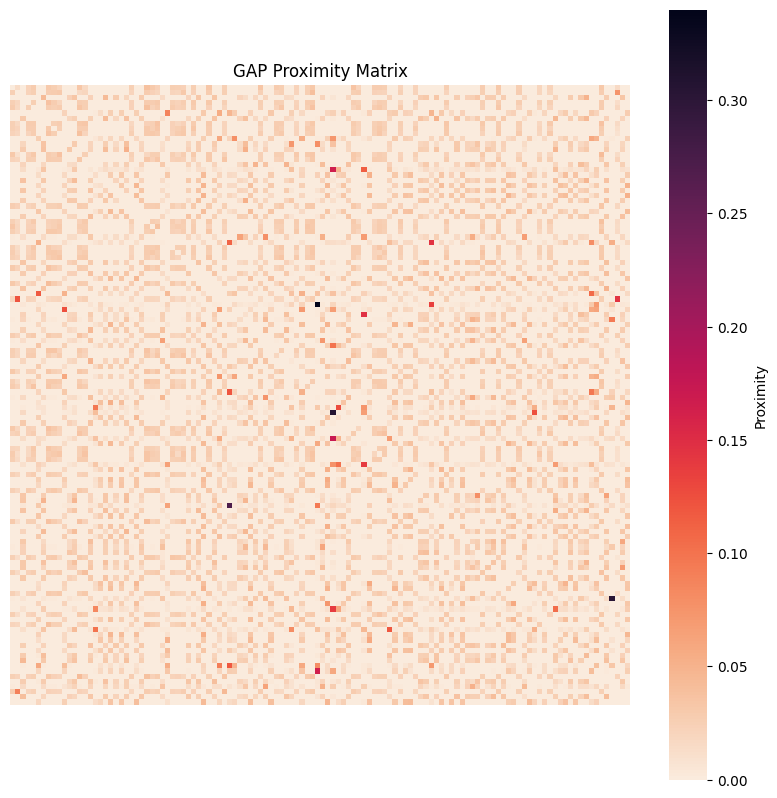

Row sums :
[1.         1.         1.0000001  1.         0.99999994 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.0000001  1.         1.0000001
 1.0000001  1.         1.         1.0000001  1.0000001  1.
 1.         1.         1.         1.0000001  1.         1.
 1.0000001  1.         1.         0.99999994 1.         1.
 1.         1.         0.9999999  1.         1.         1.
 1.         1.0000001  0.99999994 1.         1.         1.
 1.         1.         0.99999994 1.         0.99999994 0.99999994
 1.0000001  1.         1.         1.0000001  0.99999994 1.
 1.         1.         1.         1.         1.         1.
 1.         1.0000001  1.         0.99999994 0.99999994 1.0000001
 1.         1.         1.         1.0000001  1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.0000001  1.         1.         1.         1.
 1.         1.         1.         1.         0.99999994 1.
 1.         1.         

In [7]:
prox_mat = prox.toarray()

# mask diagonal to emphasize off-diagonal proximities
mask = np.eye(prox_mat.shape[0], dtype=bool)
mask=None

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(prox_mat, ax=ax, cmap='rocket_r', vmin=prox_mat.min(), vmax=prox_mat.max(),
            mask=mask,
            xticklabels=False, yticklabels=False, square=True, cbar_kws={'label': 'Proximity'})
ax.set_title(f'{weight_scheme.upper()} Proximity Matrix')
plt.show()

# Check row sums
row_sums = prox_mat.sum(axis=1)
print("Row sums :")
print(row_sums)

# Check column sums
col_sums = prox_mat.sum(axis=0)
print("Column sums :")
print(col_sums)

# Show diagonal values
diag = prox.diagonal()
print("Diagonal values:")
print(diag)

# Show max off diagonal value
off_diag_max = prox_mat - np.diag(diag)
print("Max off-diagonal value:")
print(off_diag_max.max())

## Compute Out-of-Sample Proximities

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


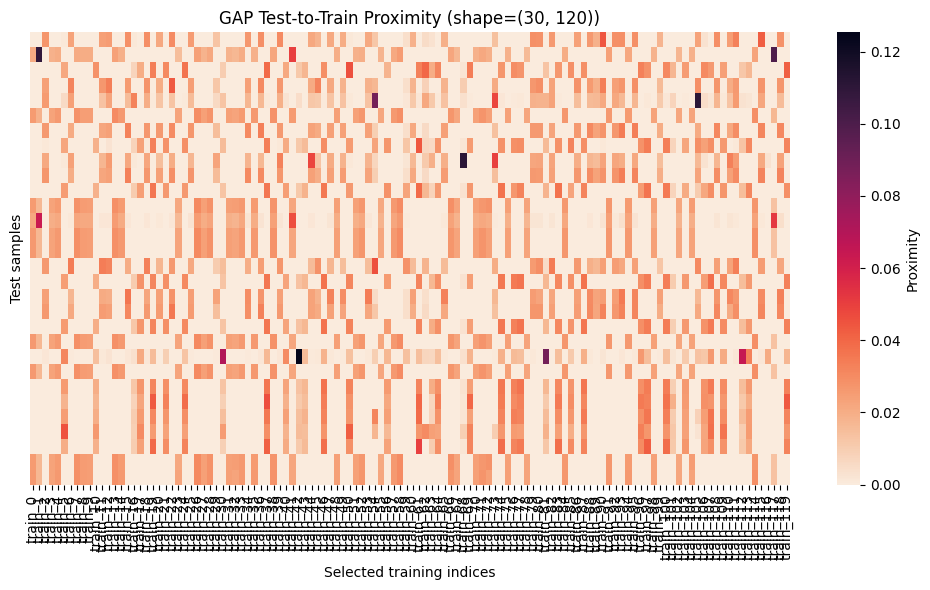

Row sums :
[0.9999998  0.9999999  0.99999994 0.9999999  0.9999999  0.9999998
 0.9999998  0.9999999  0.9999999  0.9999999  0.99999994 0.9999998
 0.99999976 0.9999998  0.9999998  0.9999998  0.99999994 0.9999999
 0.99999976 0.9999999  0.9999998  0.99999994 0.9999998  0.9999999
 0.9999999  0.9999999  0.99999994 0.9999999  0.9999998  0.9999998 ]


In [8]:
selected_train_indices = np.arange(x_train.shape[0])
test_prox = fp.transform(x_test).toarray()
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(test_prox, ax=ax, cmap='rocket_r', vmin=0, vmax=test_prox.max(),
            xticklabels=[f'train_{i}' for i in selected_train_indices],
            yticklabels=False, cbar_kws={'label': 'Proximity'})
ax.set_xlabel('Selected training indices')
ax.set_ylabel('Test samples')
ax.set_title(f'{weight_scheme.upper()} Test-to-Train Proximity (shape={test_prox.shape})')
plt.tight_layout()
plt.show()

# Check OOS proximity row sums (relevant for GAP and KeRF)
row_sums = test_prox.sum(axis=1)
print("Row sums :")
print(row_sums)

## Run Proximity-Weighted Predictions

In [9]:
classes = fp.classes_

def predict_from_proximity(P, y_reference, classes):
    y_reference = np.asarray(y_reference)
    class_proba = np.zeros((P.shape[0], len(classes)), dtype=np.float64)
    for class_index, cls in enumerate(classes):
        class_proba[:, class_index] = np.asarray(P[:, y_reference == cls].sum(axis=1)).ravel()
    predictions = classes[np.argmax(class_proba, axis=1)]
    return predictions, class_proba

test_pred, test_proba = predict_from_proximity(test_prox, y_train, classes)

In [10]:
forest_pred = fp.forest_.predict(x_test)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


In [11]:
disagree_mask = test_pred != forest_pred
print(f"Number of disagreements between matrix-based predictions and forest predictions: {np.sum(disagree_mask)} out of {len(y_test)}")

Number of disagreements between matrix-based predictions and forest predictions: 0 out of 30
